##Content Types with High Engagement

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [18]:
from pathlib import Path

data_path = Path('../data/exports')

master_df = pd.read_csv(data_path / 'master_df.csv')


In [19]:
master_df.head()

,id,image_link,user_id,created_dat,insta_filter_used,photo_type,name,created_time,private/public,post_count,verified_status,hashtag_count,hashtags,total_likes,total_comments,followers_received,following_count,total_engagement,engagement_per_follower
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,Kenton_Kirlin,16-02-2017 18:22,yes,11,no,5,"concert, drunk, fun, party, smile",25,25,77,0,50,0.649351
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,Kenton_Kirlin,16-02-2017 18:22,yes,11,no,4,"beach, landscape, photography, sunrise",36,31,77,0,67,0.870130
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,Kenton_Kirlin,16-02-2017 18:22,yes,11,no,1,beauty,38,27,77,0,65,0.844156
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,Kenton_Kirlin,16-02-2017 18:22,yes,11,no,4,"fun, happy, lol, smile",38,32,77,0,70,0.909091
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,Kenton_Kirlin,16-02-2017 18:22,yes,11,no,4,"fashion, hair, party, style",31,27,77,0,58,0.753247


In [20]:
hashtag_pref = master_df.groupby('hashtag_count').agg({
    'total_engagement' : [ 'mean', 'median', 'count'],
    'engagement_per_follower' : 'mean'

}).round(3)

hashtag_pref.columns = ['Avg_Engagement', 'Median_Engagement', 'Post_Count', 'Avg_Eng_Rate']
print("Engagement by Number of Hashtags:")
display(hashtag_pref)

# 2. Top Performing Hashtags
if 'hashtags' in master_df.columns:
    all_tags = []
    for row in master_df['hashtags'].dropna():
        all_tags.extend([tag.strip() for tag in row.split(',') if tag.strip()])
    
    from collections import Counter
    tag_count = Counter(all_tags)
    
    top_tags = pd.DataFrame(tag_count.most_common(15), columns=['Hashtag', 'Usage_Count'])
    print("\n Top 15 Most Used Hashtags:")
    display(top_tags)

Engagement by Number of Hashtags:


,Avg_Engagement,Median_Engagement,Post_Count,Avg_Eng_Rate
hashtag_count,,,,
0,63.045,63.0,67,0.827
1,63.213,62.0,47,0.828
2,63.023,62.0,43,0.826
3,63.540,63.0,50,0.834
4,63.625,64.0,32,0.833
5,64.000,63.0,18,0.838



 Top 15 Most Used Hashtags:


,Hashtag,Usage_Count
0,smile,59
1,beach,42
2,party,39
3,fun,38
4,concert,24
5,lol,24
6,food,24
7,hair,23
8,happy,22
9,beauty,20


In [23]:
content_df = master_df.copy()

# Use a function that accepts the hashtag count (a scalar) since we'll apply it to the Series
def get_content_type_from_count(hashtag_count):
    if pd.isna(hashtag_count):
        return "Unknown"
    try:
        cnt = int(hashtag_count)
    except Exception:
        return "Unknown"

    if cnt <= 5:
        return "Simple Image / Basic Post"
    elif cnt <= 10:
        return "Educational / Carousel Style"
    elif cnt <= 15:
        return "High Engagement Content"
    else:
        return "Aggressive Marketing / Trend Post"

# Apply to the hashtag_count Series (passes scalar values to the function)
content_df['content_type'] = content_df['hashtag_count'].apply(get_content_type_from_count)

# Optional: create caption length and override content type for long captions
if 'caption' in content_df.columns:
    content_df['caption_length'] = content_df['caption'].astype(str).str.len()
    content_df['content_type'] = np.where(
        content_df['caption_length'] > 100,
        "Detailed Educational Post",
        content_df['content_type']
    )

In [39]:
content_analysis = content_df.groupby('content_type').agg({
    'total_engagement': ['mean', 'median', 'count'],
    'engagement_per_follower': 'mean',
    'total_likes': 'mean',
    'total_comments': 'mean',
    'hashtag_count': 'mean'
}).round(2)

content_analysis.columns = ['Avg_Engagement', 'Median_Engagement', 'Post_Count', 
                           'Avg_Engagement_Rate', 'Avg_Likes', 'Avg_Comments', 'Avg_Hashtags']
print(" (-_-) ENGAGEMENT BY CONTENT TYPE")
display(content_analysis.sort_values('Avg_Engagement', ascending=False))


 (-_-) ENGAGEMENT BY CONTENT TYPE


,Avg_Engagement,Median_Engagement,Post_Count,Avg_Engagement_Rate,Avg_Likes,Avg_Comments,Avg_Hashtags
content_type,,,,,,,
Simple Image / Basic Post,63.31,63.0,257,0.83,34.17,29.14,1.95


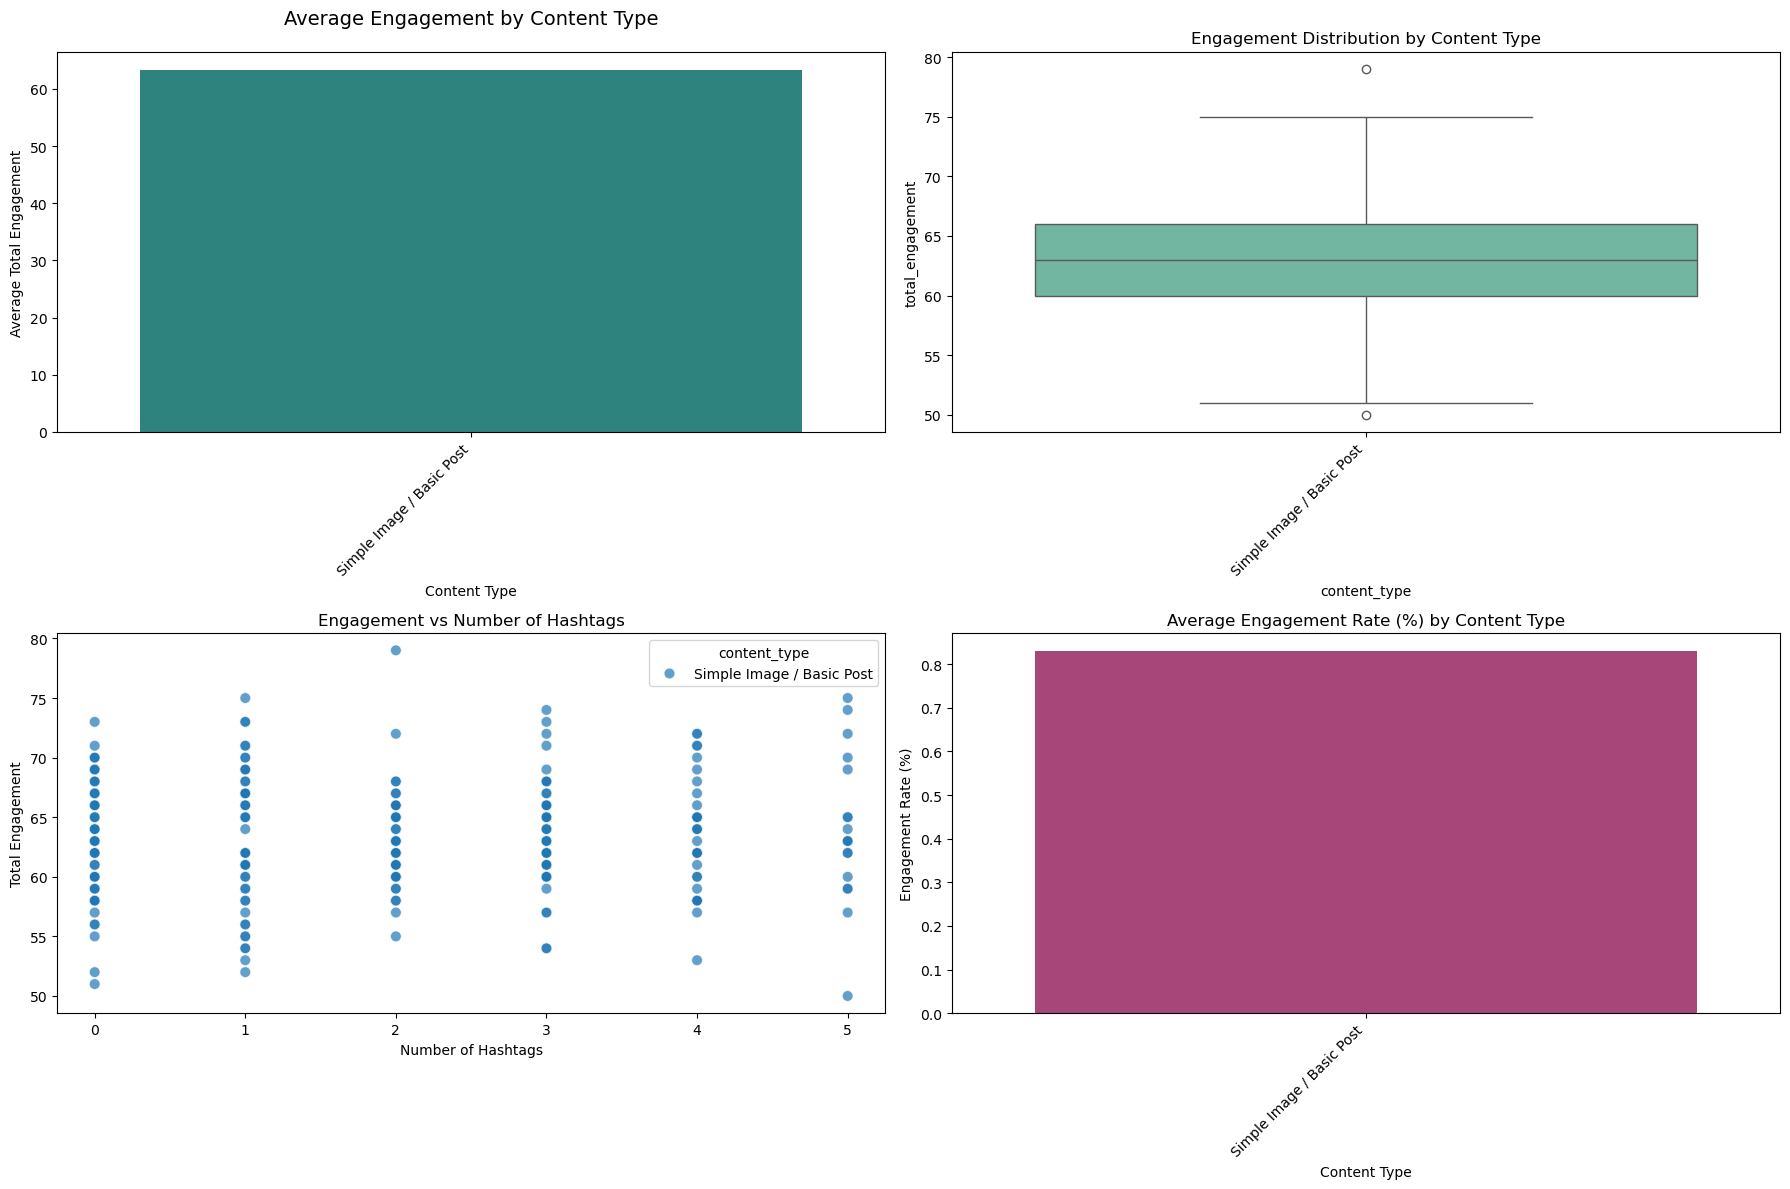

In [40]:
plt.figure(figsize=(18, 12))

# 1. Bar Chart - Average Engagement by Content Type
plt.subplot(2, 2, 1)
sns.barplot(data=content_analysis.reset_index(), 
            x='content_type', y='Avg_Engagement', palette='viridis')
plt.title('Average Engagement by Content Type', fontsize=14, pad=20)
plt.xlabel('Content Type')
plt.ylabel('Average Total Engagement')
plt.xticks(rotation=45, ha='right')

# 2. Box Plot - Engagement Distribution
plt.subplot(2, 2, 2)
sns.boxplot(data=content_df, x='content_type', y='total_engagement', palette='Set2')
plt.title('Engagement Distribution by Content Type')
plt.xticks(rotation=45, ha='right')

# 3. Scatter Plot - Hashtags vs Engagement
plt.subplot(2, 2, 3)
sns.scatterplot(data=content_df, x='hashtag_count', y='total_engagement', 
                hue='content_type', alpha=0.7, s=60)
plt.title('Engagement vs Number of Hashtags')
plt.xlabel('Number of Hashtags')
plt.ylabel('Total Engagement')

# 4. Engagement Rate Comparison
plt.subplot(2, 2, 4)
sns.barplot(data=content_analysis.reset_index(), 
            x='content_type', y='Avg_Engagement_Rate', palette='magma')
plt.title('Average Engagement Rate (%) by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

🏆 TOP 5 POSTS BY CONTENT TYPE


🔹 Simple Image / Basic Post (Top 5)


,photo_id,total_engagement,engagement_per_follower,hashtag_count,total_likes,total_comments
12,13,79,1.039474,2,40,39
144,145,75,0.986842,5,48,27
146,147,75,0.986842,1,41,34
117,118,74,0.973684,3,39,35
226,227,74,0.973684,5,39,35



High-engagement content types: ['Simple Image / Basic Post']


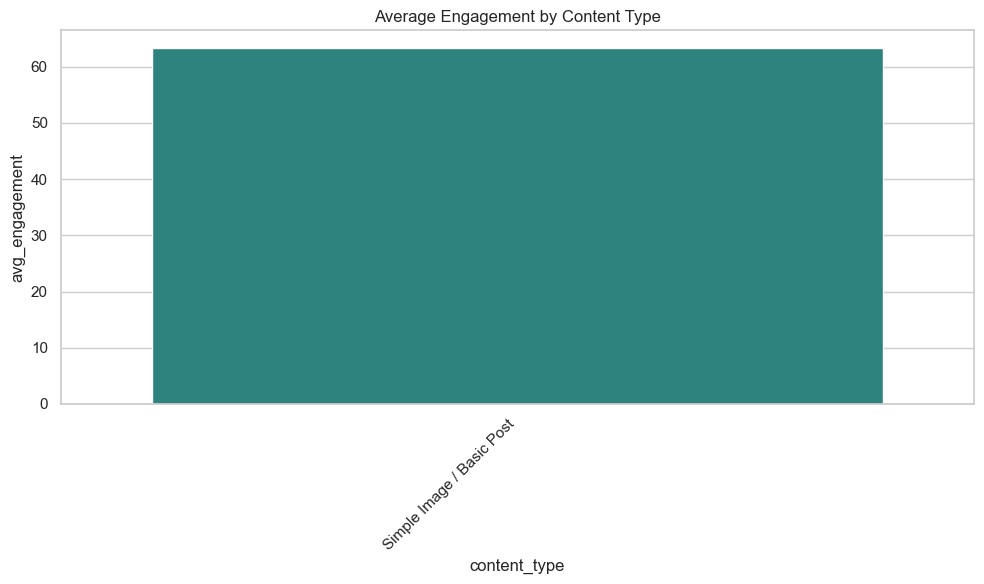

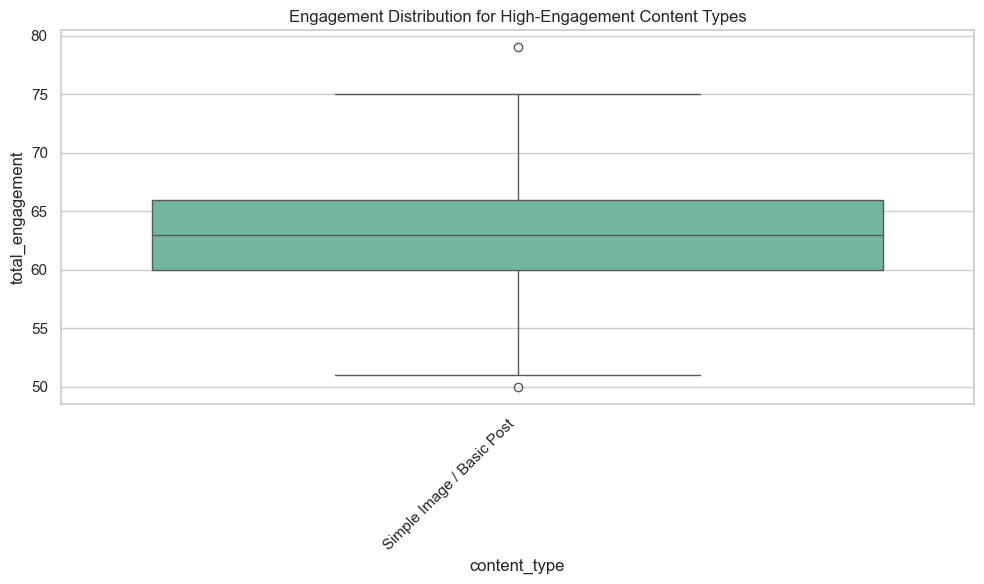

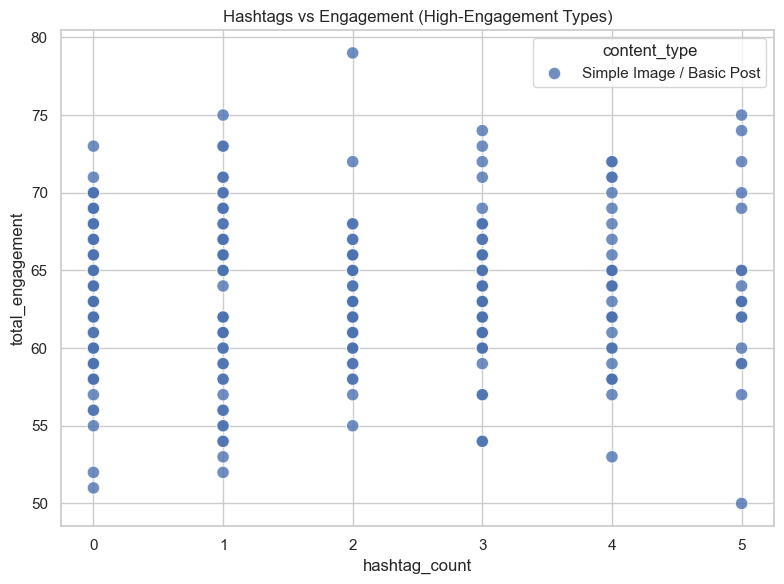

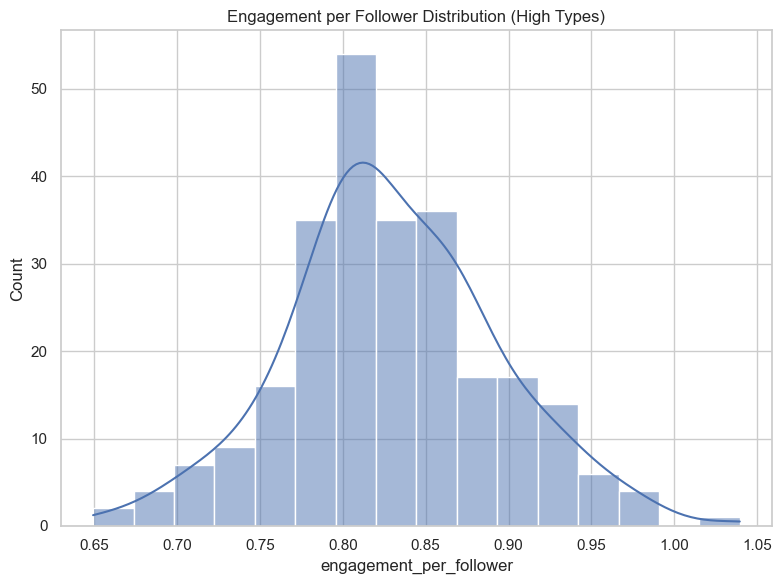


Saved plots to: C:\Users\lenovo\OneDrive\Documents\INSTAGRAM data analysis\data\exports\plots


In [ ]:
# Ensure expected column names exist (fallbacks from exported master_df variations)
if 'photo_id' not in content_df.columns:
    if 'id' in content_df.columns:
        content_df['photo_id'] = content_df['id']
    else:
        content_df['photo_id'] = range(len(content_df))

if 'engagement_per_follower' not in content_df.columns and 'engagement_rate' in content_df.columns:
    content_df['engagement_per_follower'] = content_df['engagement_rate']

print("🏆 TOP 5 POSTS BY CONTENT TYPE\n")

for ctype in content_df['content_type'].unique():
    top5 = content_df[content_df['content_type'] == ctype].nlargest(5, 'total_engagement')
    print(f"\n🔹 {ctype} (Top 5)")
    display(top5[['photo_id', 'total_engagement', 'engagement_per_follower', 
                  'hashtag_count', 'total_likes', 'total_comments']].head(5))

# ------------------------------------------------
# Identify high-engagement content types and plot|
# ------------------------------------------------

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

plots_dir = Path('../data/exports/plots')
plots_dir.mkdir(parents=True, exist_ok=True)

# Compute average engagement per content type
content_avg = content_df.groupby('content_type')['total_engagement'].mean().reset_index()
content_avg = content_avg.rename(columns={'total_engagement': 'avg_engagement'})

# Choose high-engagement types as top 25% by average engagement
threshold = content_avg['avg_engagement'].quantile(0.75)
high_types = content_avg[content_avg['avg_engagement'] >= threshold]['content_type'].tolist()

print('\nHigh-engagement content types:', high_types)

# 1) Bar chart - average engagement by content type
plt.figure(figsize=(10,6))
sns.barplot(data=content_avg.sort_values('avg_engagement', ascending=False), x='content_type', y='avg_engagement', palette='viridis')
plt.title('Average Engagement by Content Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(plots_dir / 'avg_engagement_by_type.png')
plt.show()

# 2) Box plot - engagement distribution for high-engagement types
plt.figure(figsize=(10,6))
sns.boxplot(data=content_df[content_df['content_type'].isin(high_types)], x='content_type', y='total_engagement', palette='Set2')
plt.title('Engagement Distribution for High-Engagement Content Types')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(plots_dir / 'box_high_types.png')
plt.show()

# 3) Scatter - hashtags vs engagement for high-engagement types
plt.figure(figsize=(8,6))
sns.scatterplot(data=content_df[content_df['content_type'].isin(high_types)], x='hashtag_count', y='total_engagement', hue='content_type', s=80, alpha=0.8)
plt.title('Hashtags vs Engagement (High-Engagement Types)')
plt.tight_layout()
plt.savefig(plots_dir / 'scatter_high_types.png')
plt.show()

# 4) Histogram - engagement per follower for high-engagement types
plt.figure(figsize=(8,6))
sns.histplot(data=content_df[content_df['content_type'].isin(high_types)], x='engagement_per_follower', kde=True)
plt.title('Engagement per Follower Distribution (High Types)')
plt.tight_layout()
plt.savefig(plots_dir / 'engpf_hist_high_types.png')
plt.show()

print('\nSaved plots to:', plots_dir.resolve())

In [48]:
# Export Top-5 per content type, create annotated plots, and run statistical tests
from pathlib import Path
import re
from scipy import stats
import json

# Ensure content_df exists
if 'content_df' not in globals():
    content_df = master_df.copy()
    # recompute content_type if missing
    if 'content_type' not in content_df.columns and 'hashtag_count' in content_df.columns:
        content_df['content_type'] = content_df['hashtag_count'].apply(lambda x: get_content_type_from_count(x) if 'get_content_type_from_count' in globals() else 'Unknown')

exports_dir = Path('../data/exports')
exports_dir.mkdir(parents=True, exist_ok=True)

# 1) Save top-5 CSVs
top5_dir = exports_dir / 'top5'
top5_dir.mkdir(parents=True, exist_ok=True)

saved_files = []
for ctype in content_df['content_type'].dropna().unique():
    safe_name = re.sub(r'[^a-z0-9]+', '_', ctype.lower()).strip('_')
    top5 = content_df[content_df['content_type'] == ctype].nlargest(5, 'total_engagement')
    out_path = top5_dir / f'top5_{safe_name}.csv'
    top5.to_csv(out_path, index=False)
    saved_files.append(str(out_path.resolve()))

print('Saved top-5 CSVs:')
for p in saved_files:
    print(' -', p)

# 2) Annotated plots for each content type (bar chart of top5 with labels)
plots_dir = exports_dir / 'plots' / 'annotated_top5'
plots_dir.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

for ctype in content_df['content_type'].dropna().unique():
    top5 = content_df[content_df['content_type'] == ctype].nlargest(5, 'total_engagement')
    if top5.empty:
        continue
    plt.figure(figsize=(8,5))
    ax = sns.barplot(data=top5, x='photo_id', y='total_engagement', palette='Blues_d')
    plt.title(f'Top 5 by Engagement — {ctype}')
    plt.xlabel('Photo ID')
    plt.ylabel('Total Engagement')
    # annotate bars
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')
    fname = re.sub(r'[^a-z0-9]+', '_', ctype.lower()).strip('_')
    save_path = plots_dir / f'annotated_top5_{fname}.png'
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

print('Saved annotated top-5 plots to:', plots_dir.resolve())

# 3) Statistical tests across content types
# Prepare groups
groups = []
group_names = []
for name, grp in content_df.groupby('content_type'):
    vals = grp['total_engagement'].dropna().values
    if len(vals) > 0:
        groups.append(vals)
        group_names.append(name)

stats_out = {'group_counts': {name: int(len(content_df[content_df['content_type']==name])) for name in group_names}}

if len(groups) < 2:
    stats_out['error'] = 'Not enough groups with data to run tests (need >=2)'
    print(stats_out['error'])
else:
    try:
        anova_res = stats.f_oneway(*groups)
        stats_out['anova'] = {'statistic': float(anova_res.statistic), 'pvalue': float(anova_res.pvalue)}
    except Exception as e:
        stats_out['anova_error'] = str(e)

    try:
        kw_res = stats.kruskal(*groups)
        stats_out['kruskal'] = {'statistic': float(kw_res.statistic), 'pvalue': float(kw_res.pvalue)}
    except Exception as e:
        stats_out['kruskal_error'] = str(e)

    print('\nStatistical test results:')
    if 'anova' in stats_out:
        print('ANOVA F =', round(stats_out['anova']['statistic'], 4), ', p =', round(stats_out['anova']['pvalue'], 6))
    if 'kruskal' in stats_out:
        print('Kruskal-Wallis H =', round(stats_out['kruskal']['statistic'], 4), ', p =', round(stats_out['kruskal']['pvalue'], 6))

# Save stats to JSON
stats_file = exports_dir / 'content_type_stats.json'
with open(stats_file, 'w') as f:
    json.dump(stats_out, f, indent=2)

print('\nSaved statistical test summary to:', stats_file.resolve())


Saved top-5 CSVs:
 - C:\Users\lenovo\OneDrive\Documents\INSTAGRAM data analysis\data\exports\top5\top5_simple_image_basic_post.csv
Saved annotated top-5 plots to: C:\Users\lenovo\OneDrive\Documents\INSTAGRAM data analysis\data\exports\plots\annotated_top5
Not enough groups with data to run tests (need >=2)

Saved statistical test summary to: C:\Users\lenovo\OneDrive\Documents\INSTAGRAM data analysis\data\exports\content_type_stats.json
